# FairCraft AI: Artisanal Price Prediction & Analysis
## Exploratory Data Analysis (EDA)

**Project Context:** FairCraft AI helps artisans define fair, profitable, and explainable prices.
**Objective:** Analyze processed artisanal product data to understand key factors influencing price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
DATA_PATH = '../../data/processed/processed_artisans.csv'
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} records.")
df.head()

Loaded 50000 records.


,title,price,category_1,category_2,store,rating,rating_count,feature_count,image_count,description_len,weight_oz,est_base_cost,est_time_h,quality_score
0,Anemone Jewelry Beauteous November Birthstone ...,69.00,Jewelry,Rings,Anemone Jewelry,4.1,10,5,7,407,0.00,14.07,4.31,4.37
1,"Las Vegas Subway Sign Print - Caesar's, Freemo...",19.95,Home & Kitchen,Artwork,Generic,1.0,1,0,3,624,0.00,6.24,2.25,1.60
2,Round Cut Cubic Zirconia Stud Earrings Fashion...,14.99,Jewelry,Earrings,VDKIDKT,4.2,2,5,6,0,1.13,10.56,3.50,4.44
3,"Baptism Stickers, First Communion Stickers, Ch...",7.70,Stationery & Party Supplies,Party Supplies,Generic,4.0,7,0,5,618,0.00,6.18,2.24,4.30
4,Wedding Notebook Little Notes For The Big Day ...,22.00,Stationery & Party Supplies,Stationery,Define Design 11,4.5,3,4,3,50,0.00,8.50,3.10,4.05


### 1. Data Structure & Quality
Reviewing columns, types, and missing values.

In [2]:
df.info()
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            49992 non-null  str    
 1   price            50000 non-null  float64
 2   category_1       50000 non-null  str    
 3   category_2       50000 non-null  str    
 4   store            49870 non-null  str    
 5   rating           50000 non-null  float64
 6   rating_count     50000 non-null  int64  
 7   feature_count    50000 non-null  int64  
 8   image_count      50000 non-null  int64  
 9   description_len  50000 non-null  int64  
 10  weight_oz        50000 non-null  float64
 11  est_base_cost    50000 non-null  float64
 12  est_time_h       50000 non-null  float64
 13  quality_score    50000 non-null  float64
dtypes: float64(6), int64(4), str(4)
memory usage: 5.3 MB

Missing Values:
title                8
price                0
category_1           0
category_2           0

### 2. Statistical Analysis: Price Distribution
Evaluating the target variable.

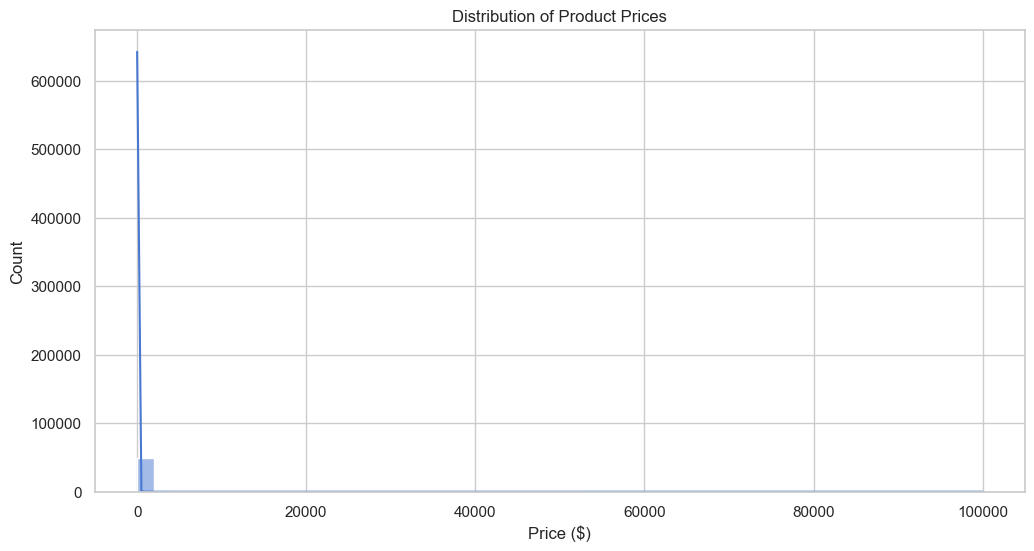

Price Descriptive Statistics:
count     50000.000000
mean         34.634238
std         452.152101
min           0.350000
25%          12.990000
50%          19.990000
75%          32.900000
max      100000.000000
Name: price, dtype: float64


In [3]:
sns.histplot(df['price'], kde=True, bins=50)
plt.title("Distribution of Product Prices")
plt.xlabel("Price ($)")
plt.show()

print("Price Descriptive Statistics:")
print(df['price'].describe())

### 3. Feature Relationship: Cost vs Price
Checking how estimated base cost influences the recommended price.

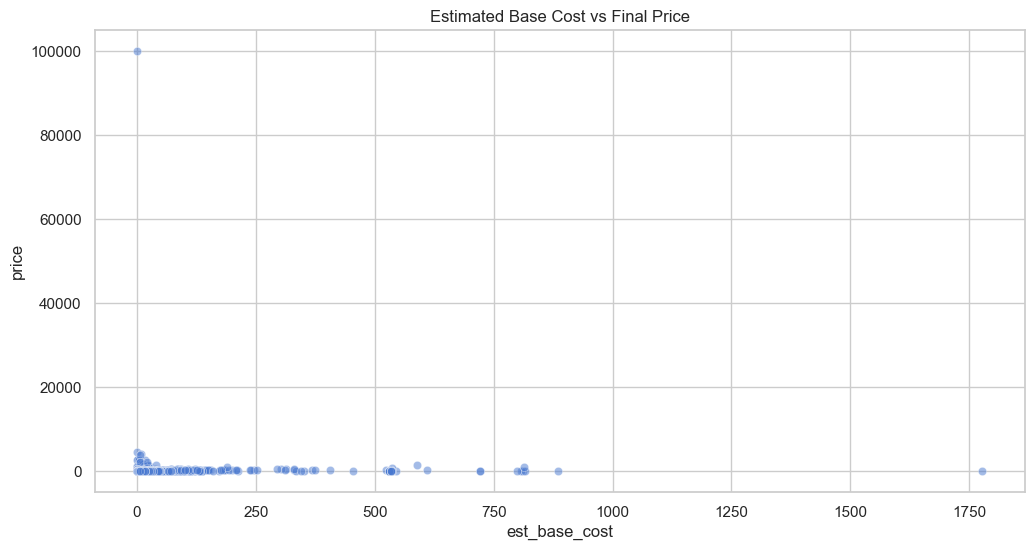

In [4]:
sns.scatterplot(data=df, x='est_base_cost', y='price', alpha=0.5)
plt.title("Estimated Base Cost vs Final Price")
plt.show()

### 4. Categorical Analysis
Price variations across different artisanal categories.

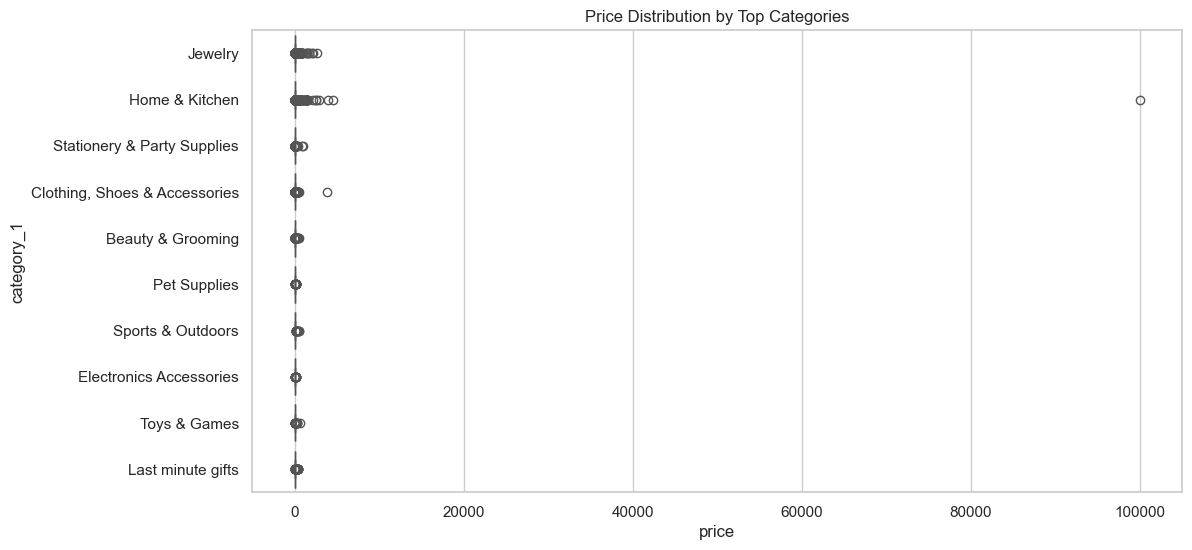

In [5]:
top_categories = df['category_1'].value_counts().head(10).index
sns.boxplot(data=df[df['category_1'].isin(top_categories)], x='price', y='category_1')
plt.title("Price Distribution by Top Categories")
plt.show()

### 5. Legal & Ethical Metadata

**Data Format:** CSV (UTF-8) containing artisanal product features derived from raw marketplace data.
**Data Quality:** Data has been filtered for missing prices and zero-values. All categorical features are derived from marketplace tags.
**Legal Constraints:** 
- **GDPR:** No Personally Identifiable Information (PII) of artisans is included. Store names are public marketplace identifiers.
- **EU AI Act Awareness:** This system is classified as 'Decision Support'. It provides recommendations, not automated pricing without human oversight. The final decision remains with the artisan.